# Part 1: Intuition and Simulation of Basic Concepts

## Objective

In this section, you should examine the fundamental concepts of probability from both an **analytical perspective** (formulas and manual calculations) and a **computational perspective** (Monte Carlo simulation in R and visual representation).

## Note:

Use code in the analytical sections as well ( use code to implement analytical part note text! ).



## Exercise 1: Airport Security System (Law of Total Probability and Conditional Probability)


### Scenario

The airport scanning device has the following characteristics:

* $P(Object) = 0.05$
* $P(Alarm \mid Object) = 0.90$
* $P(Alarm \mid \neg Object) = 0.08$


### Steps

1. Compute $P(\text{Alarm})$ using the law of total probability.

2. Compute the conditional probability $P(\text{Object}\mid \text{Alarm})$ using Bayes' theorem.

3. Simulation in R (at least 100,000 passengers).

   * First, simulate the status of having / not having the object.
   * Then, conditionally simulate whether the alarm sounds.
   * Obtain empirical estimates of $P(\text{Alarm})$ and $P(\text{Object}\mid \text{Alarm})$.

4. Compare the analytical results and the simulation in a bar chart.

5. **Challenge:**

   * For each parameter set, compute the **empirical estimate of $P(\text{Object}\mid \text{Alarm})$** using different numbers of simulation runs (N) (for example (N=10, 100, 500, 1000, 5000, 10000)) to **demonstrate convergence of the empirical estimate to the theoretical value**.


In [ ]:
################################
# 1. Compute P(Alarm)
################################
p_obj <- 0.05
p_alarm_given_object <- 0.9
p_alarm_given_no_object <- 0.08

p_alarm <- p_obj * p_alarm_given_object + (1 - p_obj) * p_alarm_given_no_object
cat("P(Alarm) =", p_alarm)

P(Alarm) = 0.121

In [ ]:
################################
# 2. Compute P(Object|Alarm) with bayes
################################
p_obj_given_alarm <- p_alarm_given_object * p_obj / p_alarm
cat("P(Object|Alarm) =", p_obj_given_alarm)

P(Object|Alarm) = 0.3719008

In [ ]:
################################
# 3. Simulate the status of having/not having the object
################################

N <- 100000

has_object <- rbinom(N, 1, p_obj)

alarm_sounds <- integer(N)
alarm_sounds[has_object == 1] <- rbinom(sum(has_object == 1), 1, p_alarm_given_object)
alarm_sounds[has_object == 0] <- rbinom(sum(has_object == 0), 1, p_alarm_given_no_object)

empirical_p_alarm <- sum(alarm_sounds) / N
empirical_p_obj_given_alarm <- sum(has_object == 1 & alarm_sounds == 1) / sum(alarm_sounds == 1)

cat("Empirical P(Alarm):", empirical_p_alarm, "\n")
cat("Empirical P(Object | Alarm):", empirical_p_obj_given_alarm, "\n")

Empirical P(Alarm): 0.12086 
Empirical P(Object | Alarm): 0.3708423 


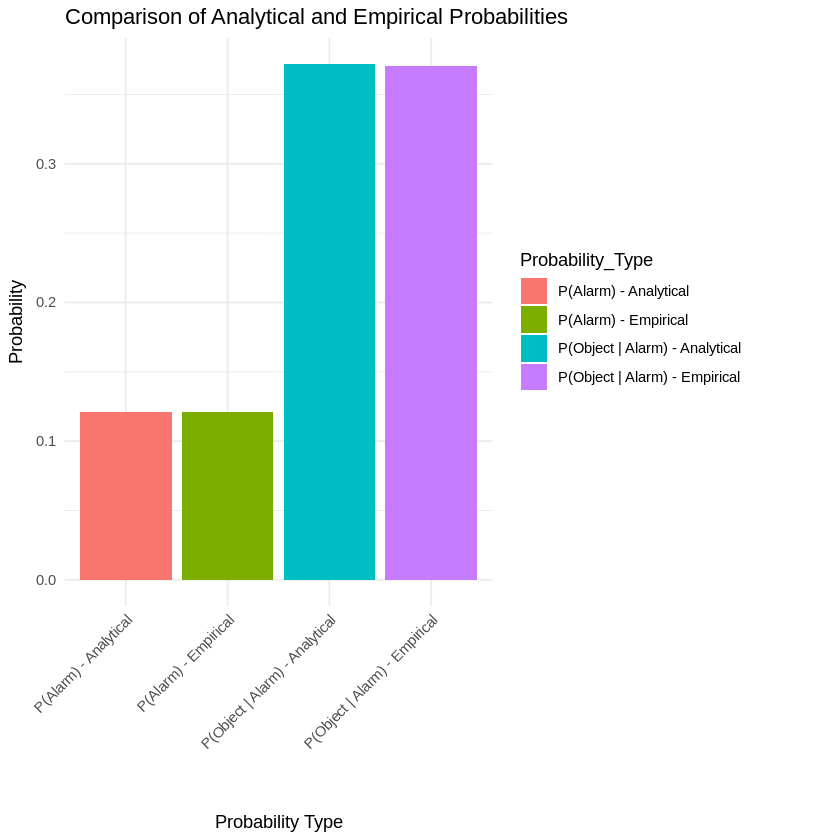

In [ ]:
################################
# 4. Comparing
################################

comparison_data <- data.frame(
  Probability_Type = c("P(Alarm) - Analytical", "P(Alarm) - Empirical",
                       "P(Object | Alarm) - Analytical", "P(Object | Alarm) - Empirical"),
  Probability_Value = c(p_alarm, empirical_p_alarm,
                        p_obj_given_alarm, empirical_p_obj_given_alarm)
)

library(ggplot2)

ggplot(comparison_data, aes(x = Probability_Type, y = Probability_Value, fill = Probability_Type)) +
  geom_bar(stat = "identity") +
  labs(title = "Comparison of Analytical and Empirical Probabilities",
       y = "Probability",
       x = "Probability Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

       N Empirical_P_Obj_Given_Alarm Theoretical_P_Obj_Given_Alarm
1     10                   0.0000000                     0.3719008
2    100                   0.2105263                     0.3719008
3    500                   0.3392857                     0.3719008
4   1000                   0.3750000                     0.3719008
5   5000                   0.3475410                     0.3719008
6  10000                   0.3726454                     0.3719008
7  50000                   0.3653624                     0.3719008
8 100000                   0.3665342                     0.3719008


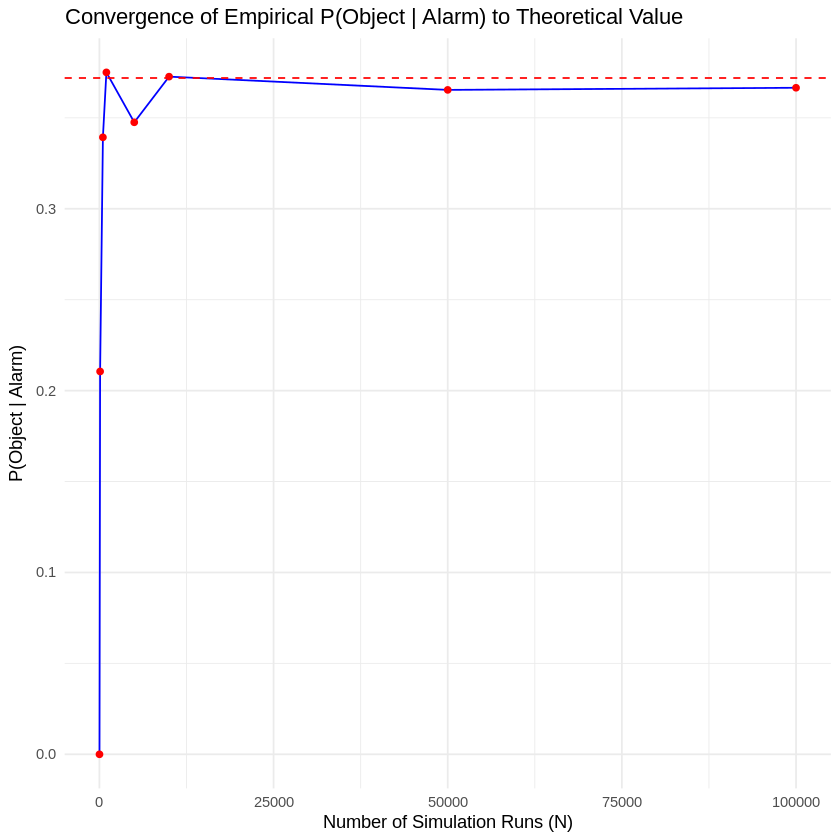

In [ ]:
################################
# 5. Challenge : Compute the empirical estimate
################################

simulation_sizes <- c(10, 100, 500, 1000, 5000, 10000, 50000, 100000)

convergence_results <- data.frame(N = integer(),
                                  Empirical_P_Obj_Given_Alarm = numeric())


for (n_sim in simulation_sizes) {

  has_object <- rbinom(n_sim, 1, p_obj)

  alarm_sounds <- integer(n_sim)
  alarm_sounds[has_object == 1] <- rbinom(sum(has_object == 1), 1, p_alarm_given_object)
  alarm_sounds[has_object == 0] <- rbinom(sum(has_object == 0), 1, p_alarm_given_no_object)

  if (sum(alarm_sounds) > 0) {
    empirical_p_obj_given_alarm_n <- sum(has_object == 1 & alarm_sounds == 1) / sum(alarm_sounds == 1)
  } else {
    empirical_p_obj_given_alarm_n <- NA
  }


  convergence_results <- rbind(convergence_results,
                               data.frame(N = n_sim,
                                          Empirical_P_Obj_Given_Alarm = empirical_p_obj_given_alarm_n))
}

options(scipen=999)
convergence_results$Theoretical_P_Obj_Given_Alarm <- p_obj_given_alarm
print(convergence_results)

library(ggplot2)
ggplot(convergence_results, aes(x = N, y = Empirical_P_Obj_Given_Alarm)) +
  geom_line(color = "blue") +
  geom_point(color = "red") +
  geom_hline(yintercept = p_obj_given_alarm, linetype = "dashed", color = "red") +
  labs(title = "Convergence of Empirical P(Object | Alarm) to Theoretical Value",
       x = "Number of Simulation Runs (N)",
       y = "P(Object | Alarm)") +
  theme_minimal()

## Exercise 2: Fraud Detection in Card Readers (Bayes’ Theorem)


### Scenario

An online store has a fraud detection system:

* $P(\text{Fraud}) = 0.02$
* $P(\text{OddCountry} \mid \text{Fraud}) = 0.70$
* $P(\text{OddCountry} \mid \neg \text{Fraud}) = 0.05$


In addition to the “OddCountry” feature, a second feature called **LargeTransactionAmount** is introduced:

* $P(\text{LargeTransactionAmount} \mid \text{Fraud}) = 0.60$
* $P(\text{LargeTransactionAmount} \mid \neg \text{Fraud}) = 0.10$


### Steps

1. **Analytical Calculation:**

   * Use Bayes’ theorem to calculate: if a transaction comes from an odd country, what is the probability of fraud?

2. **Dataset Simulation:**

   * Create a synthetic dataset of 200,000 transactions in R.
   * For each transaction, generate a “Fraud/No Fraud” label.
   * Conditionally simulate the features “OddCountry” and “LargeTransactionAmount.”
   * Compute the empirical probability $P(\text{Fraud} \mid \text{OddCountry})$ from the simulated data.

3. **Comparison:**

   * Compare analytical and empirical results using a bar chart.

4. **Challenge 1 – Naive Bayes with Two Features:**

   * Assume the features are independent and calculate:
     $$
     P(\text{Fraud} \mid \text{OddCountry}, \text{LargeTransactionAmount})
     $$
   * Estimate this probability empirically from the dataset and compare it to the theoretical value.

5. **Challenge 2 – Convergence Analysis:**

   * For $P(\text{Fraud} \mid \text{OddCountry}, \text{LargeTransactionAmount})$:

     * Run simulations with different sample sizes (N) (e.g., 1000, 5000, 10000, 50000, 100000, 200000).
     * Plot a graph showing how the empirical probability converges to the theoretical value.

6. **Challenge 3 – Sensitivity Analysis:**

   * Examine transactions that are both from an odd country **and** have a large transaction amount, and determine the probability of fraud.


In [ ]:
################################
# 1. Analytical Calculation
################################
p_fraud <- 0.02
p_odd_if_fraud <- 0.70
p_odd_if_no <- 0.05

p_odd <- p_fraud*p_odd_if_fraud + (1-p_fraud)*p_odd_if_no
p_fraud_if_odd <- p_fraud*p_odd_if_fraud / p_odd

cat("P(Fraud|OddCountry) =", p_fraud_if_odd)

P(Fraud|OddCountry) = 0.2222222

In [ ]:
################################
# 2. Code for Dataset Simulation
################################

p_fraud <- 0.02
p_odd_if_fraud <- 0.70
p_odd_if_no <- 0.05
p_large_if_fraud <- 0.60
p_large_if_no <- 0.10

set.seed(123)
N <- 200000

fraud_label <- rbinom(N,1,p_fraud)

odd_country <- integer(N)
large_amount <- integer(N)
idx_fraud <- which(fraud_label==1)
idx_no <- which(fraud_label==0)

odd_country[idx_fraud] <- rbinom(length(idx_fraud),1,p_odd_if_fraud)
odd_country[idx_no] <- rbinom(length(idx_no),1,p_odd_if_no)

large_amount[idx_fraud] <- rbinom(length(idx_fraud),1,p_large_if_fraud)
large_amount[idx_no] <- rbinom(length(idx_no),1,p_large_if_no)

df <- data.frame(Fraud=fraud_label,
                 OddCountry=odd_country,
                 LargeAmount=large_amount)

empirical_p_fraud_given_odd <- sum(df$Fraud == 1 & df$OddCountry == 1) / sum(df$OddCountry == 1)
cat("Empirical P(Fraud|OddCountry) =", signif(empirical_p_fraud_given_odd, 6))

Empirical P(Fraud|OddCountry) = 0.220676

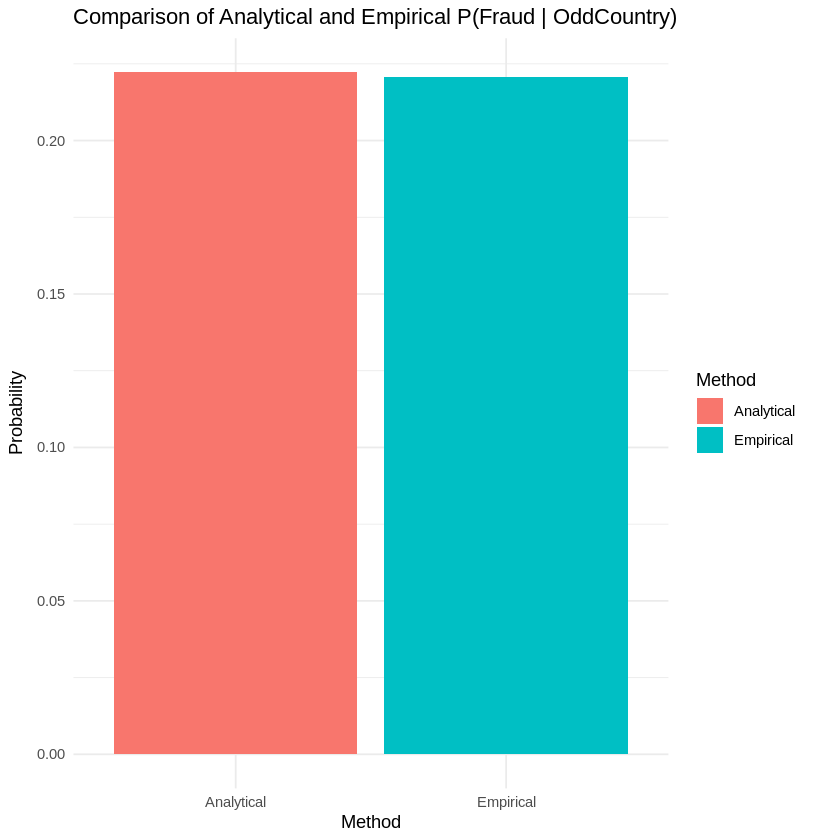

In [ ]:
################################
# 3. Comparison
################################
comparison_df <- data.frame(
  Method = c("Analytical", "Empirical"),
  Probability = c(p_fraud_if_odd, empirical_p_fraud_given_odd)
)

library(ggplot2)
ggplot(comparison_df, aes(x = Method, y = Probability, fill = Method)) +
  geom_bar(stat = "identity") +
  labs(title = "Comparison of Analytical and Empirical P(Fraud | OddCountry)",
        y = "Probability",
        x = "Method") +
  theme_minimal()

Analytical P(Fraud|OddCountry,LargeTransactionAmount) (Independent Features) = 0.6315789 
Empirical P(Fraud|OddCountry,LargeTransactionAmount) = 0.6197339 


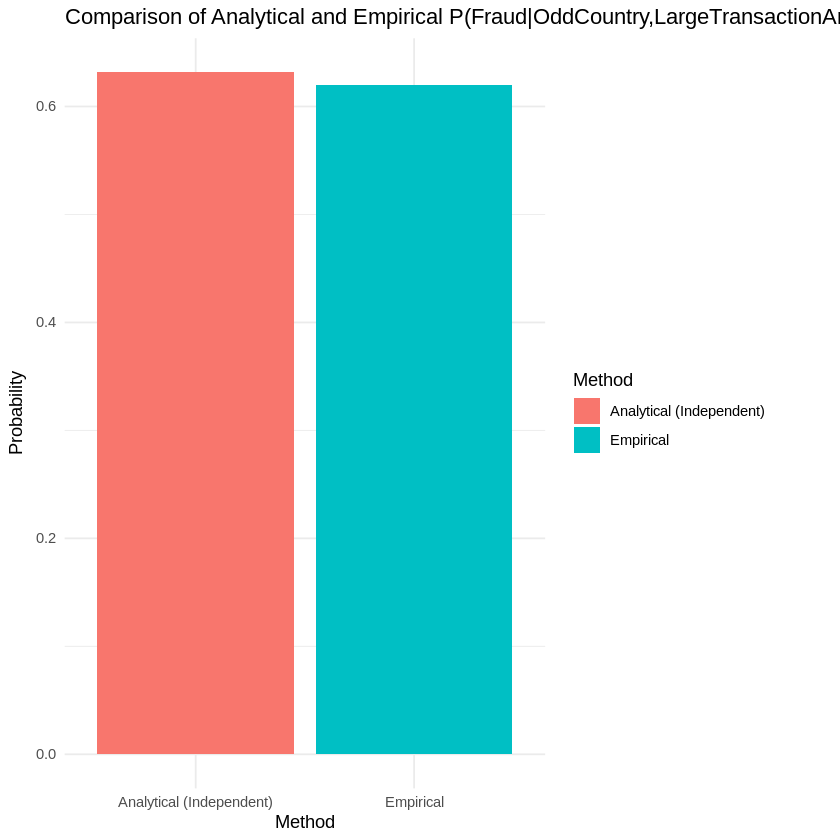

In [ ]:
################################
# 4. Challenge 1 – Naive Bayes with Two Features
################################

p_odd_and_large_if_fraud_indep <- p_odd_if_fraud * p_large_if_fraud
p_odd_and_large_if_no_indep <- p_odd_if_no * p_large_if_no

p_odd_and_large_indep <- p_odd_and_large_if_fraud_indep * p_fraud + p_odd_and_large_if_no_indep * (1 - p_fraud)
analytical_p_fraud_given_odd_large_indep <- (p_odd_and_large_if_fraud_indep * p_fraud) / p_odd_and_large_indep
cat("Analytical P(Fraud|OddCountry,LargeTransactionAmount) (Independent Features) =", analytical_p_fraud_given_odd_large_indep, "\n")

numerator_empirical <- sum(df$Fraud == 1 & df$OddCountry == 1 & df$LargeAmount == 1)
denominator_empirical <- sum(df$OddCountry == 1 & df$LargeAmount == 1)

if (denominator_empirical > 0) {
  empirical_p_fraud_given_odd_large <- numerator_empirical / denominator_empirical
  cat("Empirical P(Fraud|OddCountry,LargeTransactionAmount) =", empirical_p_fraud_given_odd_large, "\n")

  comparison_df_challenge1 <- data.frame(
    Method = c("Analytical (Independent)", "Empirical"),
    Probability = c(analytical_p_fraud_given_odd_large_indep, empirical_p_fraud_given_odd_large)
  )

  library(ggplot2)
  ggplot(comparison_df_challenge1, aes(x = Method, y = Probability, fill = Method)) +
    geom_bar(stat = "identity") +
    labs(title = "Comparison of Analytical and Empirical P(Fraud|OddCountry,LargeTransactionAmount)",
          y = "Probability",
          x = "Method") +
    theme_minimal()
} else {
  cat("No transactions found with both OddCountry and LargeTransactionAmount in the simulated data.\n")
}


       N Empirical_P_Fraud_Given_OddLarge Theoretical_P_Fraud_Given_OddLarge
1   1000                        0.8461538                          0.6315789
2   5000                        0.7272727                          0.6315789
3  10000                        0.6183206                          0.6315789
4  50000                        0.6409091                          0.6315789
5 100000                        0.6241299                          0.6315789
6 200000                        0.6414671                          0.6315789


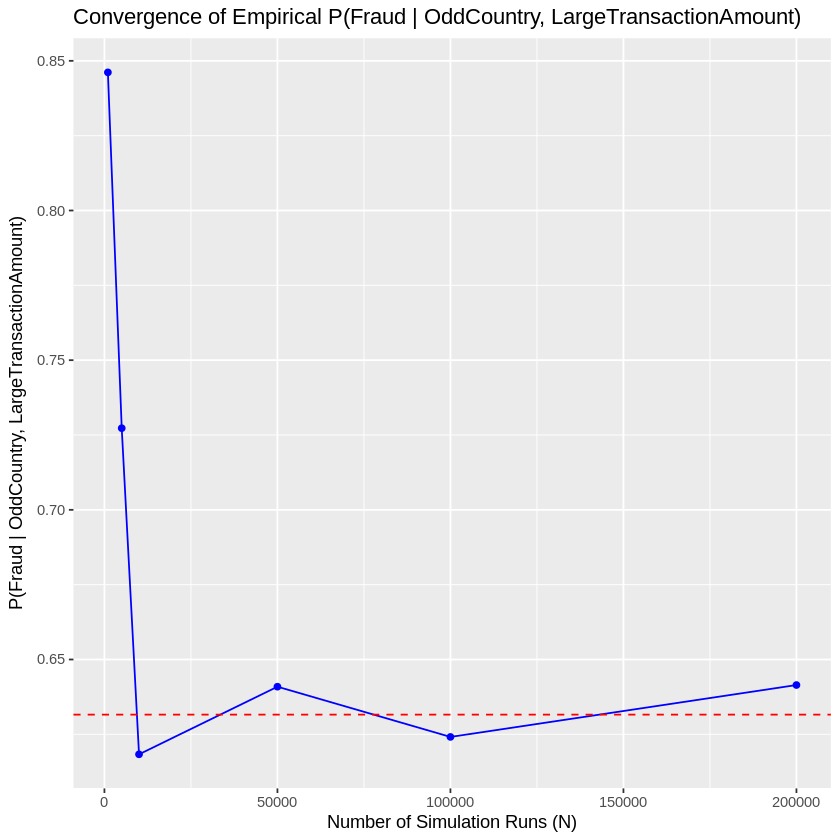

In [ ]:
################################
# 5. Challenge 2 – Convergence Analysis
################################

simulation_sizes_ex2 <- c(1000, 5000, 10000, 50000, 100000, 200000)
convergence_results_ex2 <- data.frame(N = integer(),
                                      Empirical_P_Fraud_Given_OddLarge = numeric())

p_odd_and_large_if_fraud <- p_odd_if_fraud * p_large_if_fraud
p_odd_and_large_if_no <- p_odd_if_no * p_large_if_no
p_odd_and_large <- p_odd_and_large_if_fraud * p_fraud + p_odd_and_large_if_no * (1 - p_fraud)
analytical_p_fraud_given_odd_large <- (p_odd_and_large_if_fraud * p_fraud) / p_odd_and_large


for (n_sim in simulation_sizes_ex2) {

  fraud_label <- rbinom(n_sim, 1, p_fraud)

  odd_country <- integer(n_sim)
  large_amount <- integer(n_sim)
  idx_fraud <- which(fraud_label == 1)
  idx_no <- which(fraud_label == 0)

  odd_country[idx_fraud] <- rbinom(length(idx_fraud), 1, p_odd_if_fraud)
  odd_country[idx_no] <- rbinom(length(idx_no), 1, p_odd_if_no)

  large_amount[idx_fraud] <- rbinom(length(idx_fraud), 1, p_large_if_fraud)
  large_amount[idx_no] <- rbinom(length(idx_no), 1, p_large_if_no)

  sim_df <- data.frame(Fraud = fraud_label,
                       OddCountry = odd_country,
                       LargeAmount = large_amount)

  numerator <- sum(sim_df$Fraud == 1 & sim_df$OddCountry == 1 & sim_df$LargeAmount == 1)
  denominator <- sum(sim_df$OddCountry == 1 & sim_df$LargeAmount == 1)

  if (denominator > 0) {
    empirical_p_fraud_given_odd_large_n <- numerator / denominator
  } else {
    empirical_p_fraud_given_odd_large_n <- NA
  }

  convergence_results_ex2 <- rbind(convergence_results_ex2,
                                   data.frame(N = n_sim,
                                              Empirical_P_Fraud_Given_OddLarge = empirical_p_fraud_given_odd_large_n))
}

convergence_results_ex2$Theoretical_P_Fraud_Given_OddLarge <- analytical_p_fraud_given_odd_large

options(scipen=999)
print(convergence_results_ex2)

library(ggplot2)
ggplot(convergence_results_ex2, aes(x = N, y = Empirical_P_Fraud_Given_OddLarge)) +
  geom_line(color = "blue") +
  geom_point(color = "blue") +
  geom_hline(yintercept = analytical_p_fraud_given_odd_large, linetype = "dashed", color = "red") +
  labs(title = "Convergence of Empirical P(Fraud | OddCountry, LargeTransactionAmount)",
       x = "Number of Simulation Runs (N)",
       y = "P(Fraud | OddCountry, LargeTransactionAmount)")

In [ ]:
################################
# 6. Challenge 3 – Sensitivity Analysis
################################

if (!exists("df")) {
  cat("Error: The dataframe 'df' from Step 2 simulation is not available.\nPlease run Step 2 simulation first.\n")
} else {
  odd_large_transactions <- df[df$OddCountry == 1 & df$LargeAmount == 1, ]

  num_fraud_odd_large <- sum(odd_large_transactions$Fraud == 1)

  total_odd_large_transactions <- nrow(odd_large_transactions)

  if (total_odd_large_transactions > 0) {
    empirical_p_fraud_given_odd_large_empirical <- num_fraud_odd_large / total_odd_large_transactions
    cat("Empirical P(Fraud|OddCountry=1, LargeTransactionAmount=1):", empirical_p_fraud_given_odd_large_empirical, "\n")
  } else {
    cat("No transactions found with both OddCountry and LargeTransactionAmount in the simulated data.\n")
  }
}

Empirical P(Fraud|OddCountry=1, LargeTransactionAmount=1): 0.6197339 


# Part 2: Intuitive and Classic Problems with Simulation

## **Objective:** Deepen statistical intuition and observe the power of computers for performing numerous simulations.


## 1. Monty Hall Problem


### **Scenario**

There is a TV game show with three doors. Behind one door is a prize, and the other two doors are empty. The player first chooses a door. The host (Monty), who knows what is behind each door, opens one of the empty doors and asks the player whether they want to switch their choice or stay with the original door.


### **Steps**

1. **Analytical Analysis using Conditional Probability:** Calculate the probability of winning if the player **switches** versus **stays** with the original choice.

2. **Simulation in R (10,000 runs):**

   * Randomly select the winning door.
   * Simulate the player’s decision to switch or stay.
   * Estimate the probability of winning in each scenario.

3. **Comparison:** Compare analytical and simulation results and plot a bar chart to illustrate the differences.


In [ ]:
###################################################
# 1. Analytical Analysis using Conditional Probability
###################################################

p_prize_behind_door <- 1/3

p_win_stay_if_initial_is_prize <- 1
p_win_switch_if_initial_is_prize <- 0

p_win_stay_if_initial_is_empty <- 0
p_win_switch_if_initial_is_empty <- 1

prob_win_stay <- p_win_stay_if_initial_is_prize * p_prize_behind_door + p_win_stay_if_initial_is_empty * (1-p_prize_behind_door)
prob_win_switch <- p_win_switch_if_initial_is_prize * p_prize_behind_door + p_win_switch_if_initial_is_empty * (1-p_prize_behind_door)

cat("Analytical Probability of Winning by Staying:", prob_win_stay, "\n")
cat("Analytical Probability of Winning by Switching:", prob_win_switch, "\n")

Analytical Probability of Winning by Staying: 0.3333333 
Analytical Probability of Winning by Switching: 0.6666667 


In [ ]:
#####################################
# 2. Simulation in R (10,000 runs)
#####################################

N_simulations <- 10000

win_stay <- integer(N_simulations)
win_switch <- integer(N_simulations)

set.seed(123)

for (i in 1:N_simulations) {

  winning_door <- sample(1:3, 1)
  initial_choice <- sample(1:3, 1)
  available_to_host <- setdiff(1:3, initial_choice)

  if (initial_choice == winning_door) {
    door_opened_by_host <- sample(available_to_host, 1)
  } else {
    door_opened_by_host <- setdiff(available_to_host, winning_door)
  }

  if (initial_choice == winning_door) {
    win_stay[i] <- 1
  } else {
    win_stay[i] <- 0
  }

  door_to_switch <- setdiff(1:3, c(initial_choice, door_opened_by_host))
  if (door_to_switch == winning_door) {
    win_switch[i] <- 1
  } else {
    win_switch[i] <- 0
  }
}

empirical_prob_win_stay <- sum(win_stay) / N_simulations
empirical_prob_win_switch <- sum(win_switch) / N_simulations
cat("Empirical Probability of Winning by Staying:", empirical_prob_win_stay, "\n")
cat("Empirical Probability of Winning by Switching:", empirical_prob_win_switch, "\n")

Empirical Probability of Winning by Staying: 0.3425 
Empirical Probability of Winning by Switching: 0.6575 


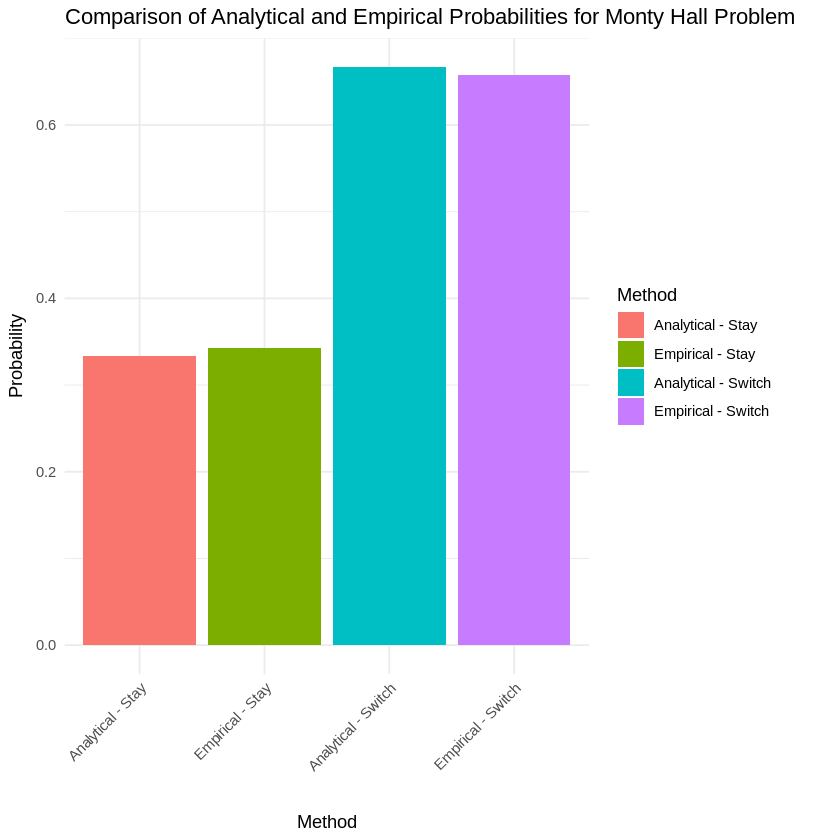

In [ ]:
#####################################
# 3. Comparison
#####################################

comparison_data_monty <- data.frame(
  Method = c("Analytical - Stay", "Empirical - Stay",
             "Analytical - Switch", "Empirical - Switch"),
  Probability = c(prob_win_stay, empirical_prob_win_stay,
                  prob_win_switch, empirical_prob_win_switch)
)

comparison_data_monty$Method <- factor(comparison_data_monty$Method,
                                      levels = c("Analytical - Stay", "Empirical - Stay",
                                                  "Analytical - Switch", "Empirical - Switch"))

library(ggplot2)
ggplot(comparison_data_monty, aes(x = Method, y = Probability, fill = Method)) +
  geom_bar(stat = "identity") +
  labs(title = "Comparison of Analytical and Empirical Probabilities for Monty Hall Problem",
       y = "Probability",
       x = "Method") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 2. Infinite Monkey Theorem


### **Scenario**

Suppose a monkey is sitting at a keyboard, pressing keys completely at random. We want to determine how long it takes for a specific word (e.g., "STAT" or "LOVE") to appear among these random sequences.


### **Steps**

**Simulation in R:**

1. Generate 1,000,000 random strings of length 4 using letters from the English alphabet.

**Empirical Probability:**

* Count how many times the target word appears exactly and compare it with the theoretical probability.

**Cumulative Probability:**

* Examine how the probability of the word appearing at least once grows as the number of strings increases (e.g., 10, 100, 1,000, 10,000, …).

**Intuitive Analysis:**

* Show why the event is almost impossible in a small simulation, but with large-scale simulations (millions of trials), the probability of occurrence becomes noticeably higher.


In [ ]:
#####################################
# 1. Generate random strings
#####################################

library(stringi)
N_strings <- 1000000
string_length <- 4
alphabet <- c(LETTERS)  # Considering only uppercase letters
random_strings <- stri_rand_strings(N_strings, string_length, pattern = "[A-Z]")

Target word: STAT 
Number of exact matches: 6 
Empirical Probability (Exact Match): 0.000006 
Theoretical Probability (Exact Match): 0.000002188299 


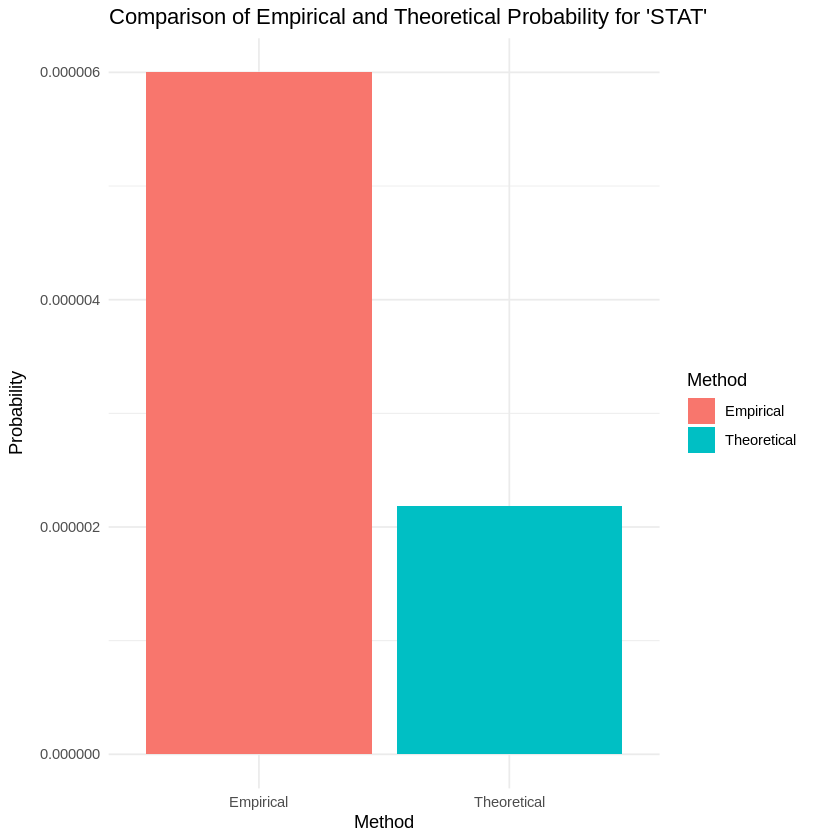

In [ ]:
#####################################
# 2. Empirical Probability
#####################################

target_word <- "STAT"

exact_matches <- sum(random_strings == target_word)
empirical_prob_exact <- exact_matches / N_strings
theoretical_prob_exact <- (1 / length(alphabet))^string_length

cat("Target word:", target_word, "\n")
cat("Number of exact matches:", exact_matches, "\n")
cat("Empirical Probability (Exact Match):", empirical_prob_exact, "\n")
cat("Theoretical Probability (Exact Match):", theoretical_prob_exact, "\n")

library(ggplot2)
comparison_prob_exact <- data.frame(
  Method = c("Empirical", "Theoretical"),
  Probability = c(empirical_prob_exact, theoretical_prob_exact)
)

ggplot(comparison_prob_exact, aes(x = Method, y = Probability, fill = Method)) +
geom_bar(stat = "identity") +
labs(title = paste("Comparison of Empirical and Theoretical Probability for '", target_word, "'", sep=""),
  y = "Probability",
  x = "Method") +
theme_minimal()

        N Empirical_Prob_At_Least_Once Theoretical_Prob_At_Least_Once
1      10                0.00005999838                  0.00002188277
2     100                0.00059982183                  0.00021880617
3    1000                0.00598205384                  0.00218590854
4   10000                0.05823563593                  0.02164531514
5  100000                0.45118935177                  0.19654179580
6 1000000                0.99752129244                  0.88789295703


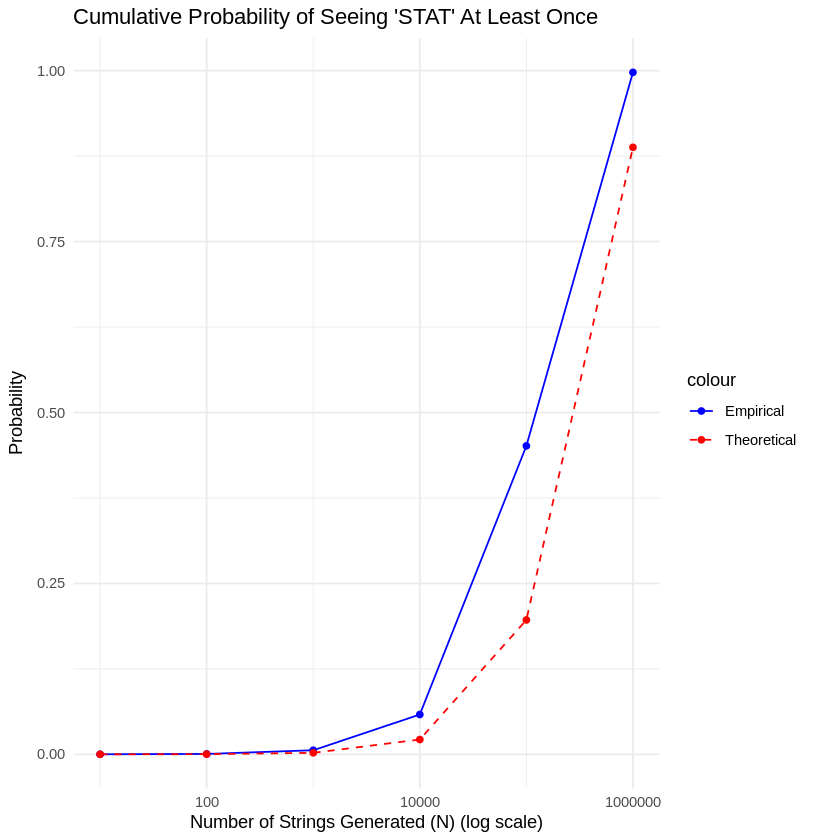

In [ ]:
#####################################
# 3. Cumulative Probability
#####################################

simulation_sizes_cum <- c(10, 100, 1000, 10000, 100000, 1000000)
cumulative_prob_results <- data.frame(N = integer(),
                                      Empirical_Prob_At_Least_Once = numeric(),
                                      Theoretical_Prob_At_Least_Once = numeric())

p_not_target <- 1 - theoretical_prob_exact
occurrence_indices <- which(random_strings == target_word)

for (n_sim in simulation_sizes_cum) {

  theoretical_prob_at_least_once_n <- 1 - (p_not_target)^n_sim
  empirical_prob_at_least_once_n <- 1 - (1 - empirical_prob_exact)^n_sim

  cumulative_prob_results <- rbind(cumulative_prob_results,
                                   data.frame(N = n_sim,
                                              Empirical_Prob_At_Least_Once = empirical_prob_at_least_once_n,
                                              Theoretical_Prob_At_Least_Once = theoretical_prob_at_least_once_n))
}

options(scipen=999)
print(cumulative_prob_results)

library(ggplot2)
ggplot(cumulative_prob_results, aes(x = N)) +
  geom_line(aes(y = Empirical_Prob_At_Least_Once, color = "Empirical")) +
  geom_point(aes(y = Empirical_Prob_At_Least_Once, color = "Empirical")) +
  geom_line(aes(y = Theoretical_Prob_At_Least_Once, color = "Theoretical"), linetype = "dashed") +
  geom_point(aes(y = Theoretical_Prob_At_Least_Once, color = "Theoretical")) +
  scale_x_log10() +
  labs(title = paste("Cumulative Probability of Seeing '", target_word, "' At Least Once", sep=""),
       x = "Number of Strings Generated (N) (log scale)",
       y = "Probability") +
  theme_minimal() +
  scale_color_manual(values = c("Empirical" = "blue", "Theoretical" = "red"))

In [ ]:
#####################################
#  4. Intuitive Analysis
#####################################

# Based on the simulation and probability calculations:
# The theoretical probability of a specific 4-letter word appearing is very low ( 1 / (26)^4 )
# In a small number of trials, the likelihood of randomly hitting this exact sequence is extremely small.
# Our simulation with a small N (ex 10 or 100) likely showed 0 occurrences, reflecting this low probability.

N_small <- 100
expected_occurrences_small <- 1 - (1 - theoretical_prob_exact)^N_small
cat("Expected occurrences at least once in 100 strings:", expected_occurrences_small, "\n")
N_large <- 1000000
expected_occurrences_big <- 1 - (1 - theoretical_prob_exact)^N_large
cat("Expected occurrences at least once in 1000000 strings:", expected_occurrences_big, "\n")

Expected occurrences at least once in 100 strings: 0.0002188062 
Expected occurrences at least once in 1000000 strings: 0.887893 


# Part 3: Modern Application – Bayesian Classification


## **Scenario**

In this section, our goal is **spam email detection**.
Each email has a label:

* **1 (Spam):** Spam email
* **0 (Not Spam):** Non-spam email

We aim to use a **Naive Bayes Classifier** to determine whether a new email is spam or not.


## **Steps**

* You can use the **tm**, **SnowballC**, **tidyverse**, **e1071** and **caret** libraries.


In [26]:
# Load required libraries
install.packages("tm")
library(tm)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [30]:
install.packages("SnowballC")
library(SnowballC)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [31]:
install.packages("caret")
library(caret)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [32]:
install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [33]:
install.packages("e1071")
library(e1071)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### Step 1: Data Preprocessing

* The data is in the file `emails.csv` (or a similar dataset can be used).

* Each row contains the content of an email and its label.

* The text needs to be preprocessed:

  * Remove punctuation
  * Convert all words to **lowercase**
  * Remove **stopwords** (words like "and", "the", "is")
  * Apply **stemming** or **lemmatization**

* Finally, each email should be converted into features that indicate whether each word is present in the text or not (0/1).

Tip: You can use R libraries for preprocessing, such as **tm** and **SnowballC**.


In [34]:
# ------------------------------------------------------
# Step 1: Load and preprocess data
# ------------------------------------------------------

# Step 1: Load dataset
emails <- read.csv("emails.csv", stringsAsFactors = FALSE)

# Assuming dataset has two columns: "text" and "spam"
head(emails)

# Step 2: Create a text corpus
corpus <- VCorpus(VectorSource(emails$text))

# Step 3: Preprocessing
corpus <- tm_map(corpus, content_transformer(tolower))           # Convert to lowercase
corpus <- tm_map(corpus, removePunctuation)                      # Remove punctuation
corpus <- tm_map(corpus, removeNumbers)                          # Remove numbers
corpus <- tm_map(corpus, removeWords, stopwords("english"))      # Remove stopwords
corpus <- tm_map(corpus, stripWhitespace)                        # Remove extra whitespace
corpus <- tm_map(corpus, stemDocument)                           # Perform stemming (optional)

# Step 4: Create Document-Term Matrix (binary: 0/1 features)
dtm <- DocumentTermMatrix(corpus, control = list(weighting = weightBin))

# Step 5: Convert DTM to dataframe and attach labels
data_features <- as.data.frame(as.matrix(dtm))
data_features$spam <- emails$spam

# Check result
str(data_features)
table(data_features$spam)

,text,spam
,<chr>,<int>
1,"Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1
2,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or continuant clothesman no libretto is chesapeake but tight not waterway herald and hawthorn like chisel morristown superior is deoxyribonucleic not clockwork try hall incredible mcdougall yes hepburn or einsteinian earmark no sapling is boar but duane not plain palfrey and inflexible like huzzah pepperoni bedtime is nameable not attire try edt chronography optima yes pirogue or diffusion albeit no,1
3,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended to you unconditionally and your credit is in no way a factor . to take advantage of this limited time opportunity all we ask is that you visit our website and complete the 1 minute post approval form look foward to hearing from you , dorcas pittman",1
4,"Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 338 - 8102 e - mail : ramsey @ goldengraphix . com request additional information now ! click here click here for a printable version of our order form ( pdf format ) golden graphix & printing 5110 azusa canyon rd . irwindale , ca 91706 this e - mail message is an advertisement and / or solicitation .",1
5,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death . all comedies are ended by marriage .",1
6,"Subject: great nnews hello , welcome to medzonline sh groundsel op we are pleased to introduce ourselves as one of the ieading online phar felicitation maceuticai shops . helter v shakedown r a cosmopolitan l l blister l l bestow ag ac tosher l is coadjutor va confidant um andmanyother . - sav inexpiable e over 75 % - total confide leisure ntiaiity - worldwide s polite hlpplng - ov allusion er 5 miilion customers in 150 countries have devitalize a nice day !",1


'data.frame':	5728 obs. of  25172 variables:
 $ aaa                     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aaaenerfax              : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aadedeji                : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aagraw                  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aal                     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aaldous                 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aaliyah                 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aall                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aanalysi                : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aaron                   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aawesom                 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ aba                     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abacha                  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abacus                  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abahi                   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abaixo                  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abandon                 


   0    1 
4360 1368 

### Step 2: Data Splitting

The data is divided into two parts:

* **Training set:** Used to calculate probabilities $P(y)$ and $P(x_i \mid y)$.
* **Test set:** Used to evaluate the model on new, unseen data.

Goal: Obtain a reliable and accurate estimate of the model’s performance on unseen data.


In [35]:
# -------------------------------
# Step 2: Split data into train/test
# -------------------------------

set.seed(123) # For reproducibility

# 80% training, 20% testing
train_index <- sample(1:nrow(data_features), 0.8 * nrow(data_features))

train_data <- data_features[train_index, ]
test_data  <- data_features[-train_index, ]

# Check dimensions of train and test sets
cat("Training set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")

table(train_data$spam)
table(test_data$spam)

Training set size: 4582 
Test set size: 1146 



   0    1 
3457 1125 


  0   1 
903 243 

### Step 3: Building the Bag of Words (BoW) Model

* In the **Bag of Words** approach, each word in the vocabulary becomes a feature.
* The feature value represents either the **count** of the word in the text or simply its **presence/absence**.
* The BoW matrix is constructed as follows:

  * Each row = one email
  * Each column = one word
  * Values = word count in the email

Example:

| Sentence                                             | like | this | food | restaurant | was | good | behavior | staff |
| ---------------------------------------------------- | ---- | ---- | ---- | ---------- | --- | ---- | -------- | ----- |
| Sentence 1: "I liked the food from this restaurant." | 1    | 1    | 1    | 1          | 1   | 0    | 0        | 0     |
| Sentence 2: "The staff's behavior was not good."     | 0    | 0    | 0    | 0          | 0   | 1    | 1        | 1     |

* Finally, the BoW matrix is built for all emails in the dataset.


In [36]:
# -------------------------------
# Step 3: Build Bag of Words (BoW)
# -------------------------------

# Create Document-Term Matrix with term frequency (not binary)
dtm_bow <- DocumentTermMatrix(corpus)

# Convert DTM to dataframe
bow_matrix <- as.data.frame(as.matrix(dtm_bow))

# Add labels
bow_matrix$spam <- emails$spam

# Inspect the structure
str(bow_matrix)

# Example: first few rows of BoW matrix
head(bow_matrix[, 1:10])  # show first 10 words as columns


'data.frame':	5728 obs. of  25172 variables:
 $ aaa                     : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aaaenerfax              : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aadedeji                : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aagraw                  : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aal                     : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aaldous                 : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aaliyah                 : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aall                    : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aanalysi                : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aaron                   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aawesom                 : num  0 0 0 0 0 0 0 0 0 0 ...
 $ aba                     : num  0 0 0 0 0 0 0 0 0 0 ...
 $ abacha                  : num  0 0 0 0 0 0 0 0 0 0 ...
 $ abacus                  : num  0 0 0 0 0 0 0 0 0 0 ...
 $ abahi                   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ abaixo                  : num  0 0 0 0 0 0 0 0 0 0 ...
 $ abandon                 

,aaa,aaaenerfax,aadedeji,aagraw,aal,aaldous,aaliyah,aall,aanalysi,aaron
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0


### Step 4: Training the Naive Bayes Model

* Using the BoW data and labels, compute the conditional probabilities:

$$
P(y) = \frac{\text{Number of emails in class } y}{\text{Total number of emails}}
$$

$$
P(x_i \mid y) = \frac{\text{Number of emails in class } y \text{ containing word } i}{\text{Number of emails in class } y}
$$

* For a new email, make a prediction using Bayes’ rule:

$$
\hat{y} = \arg\max_y ; P(y) \prod_{i=1}^D P(x_i \mid y)
$$

* To avoid zero probabilities, apply **Laplace Smoothing**:

$$
P(x_i \mid y) = \frac{\text{count}(x_i, y) + 1}{\text{count}(y) + |V|}
$$

where $|V|$ is the total number of words in the vocabulary.

**Important:** Do not use a pre-built Naive Bayes model; implement the calculations manually.


In [37]:
# -------------------------------
# Step 4: Training the Naive Bayes Model
# -------------------------------

# Separate features (X) and labels (y) for training data
train_X <- train_data[, -which(names(train_data) == "spam")]
train_y <- train_data$spam

# Calculate prior probabilities P(y)
prob_spam <- sum(train_y == 1) / length(train_y)
prob_not_spam <- sum(train_y == 0) / length(train_y)

cat("P(Spam):", prob_spam, "\n")
cat("P(Not Spam):", prob_not_spam, "\n")

# Calculate conditional probabilities P(xi | y) with Laplace smoothing
# Use the training data to build the vocabulary and calculate counts
vocabulary <- colnames(train_X)
vocab_size <- length(vocabulary)

# Initialize matrices to store counts
spam_word_counts <- colSums(train_X[train_y == 1, ])
not_spam_word_counts <- colSums(train_X[train_y == 0, ])

# Apply Laplace smoothing
# P(xi | spam) = (count(xi, spam) + 1) / (count(spam) + |V|)
# P(xi | not spam) = (count(xi, not spam) + 1) / (count(not spam) + |V|)

prob_word_given_spam <- (spam_word_counts + 1) / (sum(train_y == 1) + vocab_size)
prob_word_given_not_spam <- (not_spam_word_counts + 1) / (sum(train_y == 0) + vocab_size)

# Store the calculated probabilities for prediction
naive_bayes_model <- list(
  prob_spam = prob_spam,
  prob_not_spam = prob_not_spam,
  prob_word_given_spam = prob_word_given_spam,
  prob_word_given_not_spam = prob_word_given_not_spam,
  vocabulary = vocabulary
)

cat("\nNaive Bayes Model trained successfully.\n")

P(Spam): 0.245526 
P(Not Spam): 0.754474 

Naive Bayes Model trained successfully.


### Step 5: Calculating Accuracy on Test Data

* Compute the **accuracy** of the model on the test dataset:

$$
\text{Accuracy} = \frac{\text{Number of correctly predicted emails}}{\text{Total number of emails in the test set}}
$$


In [38]:
# -------------------------------
# Step 5: Calculating Accuracy on Test Data
# -------------------------------

# Separate features (X) and labels (y) for test data
test_X <- test_data[, -which(names(test_data) == "spam")]
test_y <- test_data$spam

# Function to make predictions using the manual Naive Bayes model
predict_naive_bayes <- function(email_features, model) {
  # Ensure test features have the same columns as the training vocabulary
  # Handle words in test set not seen in training by adding them with zero counts
  missing_cols <- setdiff(model$vocabulary, colnames(email_features))
  for(col in missing_cols) {
    email_features[[col]] <- 0
  }
  # Ensure columns are in the same order as the training vocabulary
  email_features <- email_features[, model$vocabulary]


  # Calculate log probabilities for spam and not spam classes for each email
  log_prob_spam_per_email <- log(model$prob_spam) + rowSums(log(email_features * model$prob_word_given_spam + (1 - email_features) * (1 - model$prob_word_given_spam)))
  log_prob_not_spam_per_email <- log(model$prob_not_spam) + rowSums(log(email_features * model$prob_word_given_not_spam + (1 - email_features) * (1 - model$prob_word_given_not_spam)))


  # Predict the class with the higher log probability
  predictions <- ifelse(log_prob_spam_per_email > log_prob_not_spam_per_email, 1, 0)

  return(predictions)
}

# Make predictions on the test data
preds <- predict_naive_bayes(test_X, naive_bayes_model)

# Calculate accuracy
accuracy <- mean(preds == test_y)

cat("Manual Naive Bayes Model Accuracy on Test Set:", accuracy, "\n")

Manual Naive Bayes Model Accuracy on Test Set: 0.7347295 


## Challenges and Questions

1. **Unseen Words:**
   If a word does not appear in the BoW:

2. **Very Small Probabilities:**
   Since probabilities get extremely small when multiplied, use **log probabilities**:

$$
\log P(y \mid X) \propto \log P(y) + \sum_i \log P(x_i \mid y)
$$

3. **Stopwords:**
   * does removeing them have good effect or not?
   The effect of removing stopwords can vary depending on the dataset and the specific task

4. **Model Evaluation:**

   * Compute **accuracy** on the test set.
   * Compare with a pre-built R model, e.g., `e1071::naiveBayes`.
   * Which performs better? Explain the reason for any differences.

5. **Appropriate Metrics:**

   * Is accuracy alone sufficient for evaluating model quality? Explore other evaluation methods and metrics in your code.
   * Suggested metrics: F1 score, confusion matrix, precision, recall, etc.


In [39]:
# -------------------------------
# Part 6: Evaluation with e1071::naiveBayes
# -------------------------------
library(e1071)

train_y_factor <- factor(train_y, levels=c(0,1))

nb_model <- naiveBayes(x = train_X, y = train_y_factor)

pred_e1071 <- predict(nb_model, newdata = test_X)


pred_e1071_num <- as.numeric(as.character(pred_e1071))

accuracy_e1071 <- mean(pred_e1071_num == test_y)
cat("Test Accuracy (e1071 Naive Bayes):", accuracy_e1071, "\n")


Test Accuracy (e1071 Naive Bayes): 0.2085515 


In [40]:
# -------------------------------
# Extra Evaluation Metrics
# -------------------------------

# Function to compute evaluation metrics from confusion matrix
compute_metrics <- function(true, pred, model_name="Model") {
  tab <- table(Predicted = pred, Actual = true)

  # Extract confusion matrix components
  TP <- ifelse(!is.na(tab["1","1"]), tab["1","1"], 0)
  TN <- ifelse(!is.na(tab["0","0"]), tab["0","0"], 0)
  FP <- ifelse(!is.na(tab["1","0"]), tab["1","0"], 0)
  FN <- ifelse(!is.na(tab["0","1"]), tab["0","1"], 0)

  # Compute metrics
  accuracy  <- (TP + TN) / (TP + TN + FP + FN)
  precision <- ifelse((TP + FP) == 0, NA, TP / (TP + FP))
  recall    <- ifelse((TP + FN) == 0, NA, TP / (TP + FN))
  f1        <- ifelse(is.na(precision) | is.na(recall) | (precision+recall)==0, NA,
                      2 * precision * recall / (precision + recall))

  # Print results
  cat("=== ", model_name, " ===\n")
  print(tab)
  cat(sprintf("Accuracy : %.4f\n", accuracy))
  cat(sprintf("Precision (spam=1): %.4f\n", precision))
  cat(sprintf("Recall    (spam=1): %.4f\n", recall))
  cat(sprintf("F1-score  (spam=1): %.4f\n\n", f1))

  # Return as data frame for comparison
  return(data.frame(Model=model_name, Accuracy=accuracy,
                    Precision=precision, Recall=recall, F1=f1))
}

# -------------------------------
# Run evaluation for both models
# -------------------------------

res_manual <- compute_metrics(test_y, preds, "Manual Naive Bayes")
res_e1071  <- compute_metrics(test_y, pred_e1071_num, "e1071 Naive Bayes")

# Combine results into a single summary table
results <- rbind(res_manual, res_e1071)
print(results)


===  Manual Naive Bayes  ===
         Actual
Predicted   0   1
        0 804 205
        1  99  38
Accuracy : 0.7347
Precision (spam=1): 0.2774
Recall    (spam=1): 0.1564
F1-score  (spam=1): 0.2000

===  e1071 Naive Bayes  ===
         Actual
Predicted   0   1
        0   2   6
        1 901 237
Accuracy : 0.2086
Precision (spam=1): 0.2083
Recall    (spam=1): 0.9753
F1-score  (spam=1): 0.3432

               Model  Accuracy Precision    Recall        F1
1 Manual Naive Bayes 0.7347295 0.2773723 0.1563786 0.2000000
2  e1071 Naive Bayes 0.2085515 0.2082601 0.9753086 0.3432295
